# Preços de Imóveis com Regressão Linear

**Autor: Wellington M Santos - Data Scientist**

[![LinkedIn](https://img.shields.io/badge/LinkedIn-wellington--moreira--santos-blue)](https://www.linkedin.com/in/wellington-moreira-santos)
[![Email](https://img.shields.io/badge/Email-wsantos08%40hotmail.com-red)](mailto:wsantos08@hotmail.com)

---

## Introdução

Neste projeto, precificar imóveis usando regressão linear é o objetivo central. Parto de uma base de dados inspirada na competição [House Prices, Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) do Kaggle, com adaptações feitas pelo curso para facilitar o aprendizado. Construo e comparo quatro modelos de regressão com inclusão progressiva de variáveis, avalio a multicolinearidade com VIF e analiso o comportamento dos resíduos antes de aplicar o modelo em novos imóveis.

**Seções deste notebook:**

1. Carregando e conhecendo os dados
2. Análise de correlação
3. Modelo 0: regressão simples
4. Separando em treino e teste
5. Modelos 1, 2 e 3: regressão múltipla
6. Comparando os modelos
7. Precificando imóveis novos
8. Avaliando o modelo: VIF e resíduos
9. Conclusão e Considerações Finais
10. Referências



---


## 1. Carregando e conhecendo os dados

In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

print('- BIBLIOTECAS CARREGADAS - ')
print(f'Versão Python: {sys.version.split()[0]}')

- BIBLIOTECAS CARREGADAS - 
Versão Python: 3.13.5


In [3]:
try:
    dados = pd.read_csv("Preços_de_casas.csv")
    dados = dados.drop(columns="Id")
    print('- DADOS CARREGADOS -')
except FileNotFoundError:
    print('Erro ao encontrar o arquivo, verifique o caminho fornecido.')
except Exception as e:
    print(f'Erro Desconhecido: {str(e)}')

- DADOS CARREGADOS -



Removo a coluna `Id` logo na leitura, pois é apenas um identificador de linha e não carrega informação preditiva.


In [5]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   area_primeiro_andar             1438 non-null   float64
 1   existe_segundo_andar            1438 non-null   int64  
 2   area_segundo_andar              1438 non-null   float64
 3   quantidade_banheiros            1438 non-null   int64  
 4   capacidade_carros_garagem       1438 non-null   int64  
 5   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 6   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 78.8 KB



O dataset contém 1.438 registros sem nenhum valor ausente. A tabela abaixo descreve cada variável disponível:

| Variável | Tipo | Descrição |
|---|---|---|
| `area_primeiro_andar` | float | Área do primeiro andar em m² |
| `existe_segundo_andar` | binária | 1 se há segundo andar, 0 caso contrário |
| `area_segundo_andar` | float | Área do segundo andar em m² (0 se não existir) |
| `quantidade_banheiros` | inteiro | Número total de banheiros |
| `capacidade_carros_garagem` | inteiro | Capacidade máxima de carros na garagem |
| `qualidade_da_cozinha_Excelente` | binária | 1 se a cozinha é classificada como excelente, 0 caso contrário |
| `preco_de_venda` | float | Preço de venda do imóvel em reais — variável alvo |


In [6]:
dados.describe()

,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente,preco_de_venda
count,1438.000000,1438.000000,1438.000000,1438.000000,1438.000000,1438.000000,1.438000e+03
mean,106.602556,0.431154,31.888410,1.556328,470.381780,0.065369,8.802488e+05
std,33.040598,0.495410,39.952846,0.542512,211.875916,0.247261,3.697203e+05
min,31.028600,0.000000,0.000000,0.000000,0.000000,0.000000,1.720570e+05
25%,81.682325,0.000000,0.000000,1.000000,326.000000,0.000000,6.384350e+05
50%,100.332000,0.000000,0.000000,2.000000,477.500000,0.000000,7.980438e+05
75%,127.458800,1.000000,67.631200,2.000000,576.000000,0.000000,1.045160e+06
max,223.145800,1.000000,168.892200,3.000000,1390.000000,1.000000,3.081250e+06


In [7]:
dados.head()

,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente,preco_de_venda
0,79.5224,1,79.3366,2,548,0,1027905.0
1,117.2398,0,0.0000,2,460,0,894795.0
2,85.4680,1,80.4514,2,608,0,1101855.0
3,89.2769,1,70.2324,1,642,0,690200.0
4,106.3705,1,97.8237,2,836,0,1232500.0


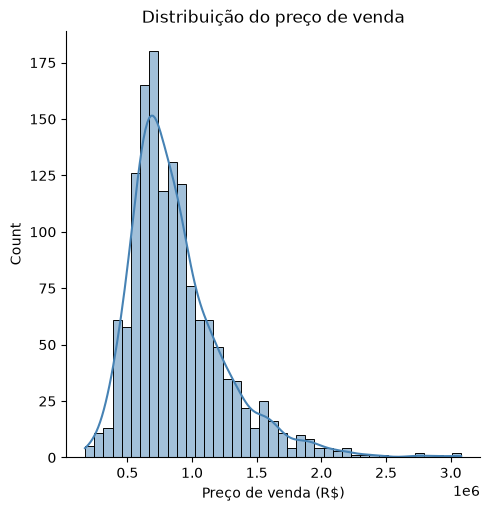

In [8]:
sns.displot(dados['preco_de_venda'], kde=True, color='steelblue')
plt.title('Distribuição do preço de venda')
plt.xlabel('Preço de venda (R$)')
plt.show()


A distribuição do preço de venda é assimétrica à direita, com concentração abaixo de R$ 1.200.000 e uma cauda formada por imóveis de alto padrão. O preço médio é R$ 880.249 e o desvio padrão é R$ 369.720.



---


## 2. Análise de correlação

In [9]:
corr = dados.corr()
corr['preco_de_venda'].sort_values(ascending=False)

preco_de_venda                    1.000000
capacidade_carros_garagem         0.640214
area_primeiro_andar               0.616557
quantidade_banheiros              0.563132
qualidade_da_cozinha_Excelente    0.496223
area_segundo_andar                0.305311
existe_segundo_andar              0.138541
Name: preco_de_venda, dtype: float64

O coeficiente de Pearson mede a intensidade e a direção da relação linear entre cada variável e o preço de venda, em escala de -1 a +1. As três mais correlacionadas são `capacidade_carros_garagem` (0,64), `area_primeiro_andar` (0,62) e `quantidade_banheiros` (0,56). A variável `existe_segundo_andar` tem a menor correlação isolada (0,14), mas veremos que sua contribuição no modelo múltiplo é relevante.

### 2.1 Avaliando Pares com Variável Resposta

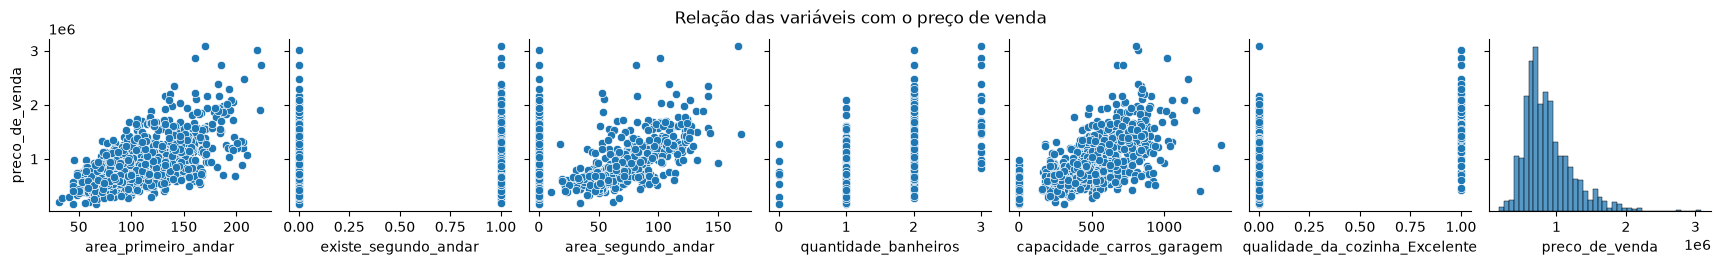

In [13]:
sns.pairplot(dados, y_vars='preco_de_venda')
plt.suptitle('Relação das variáveis com o preço de venda', y=1.02)
plt.show()

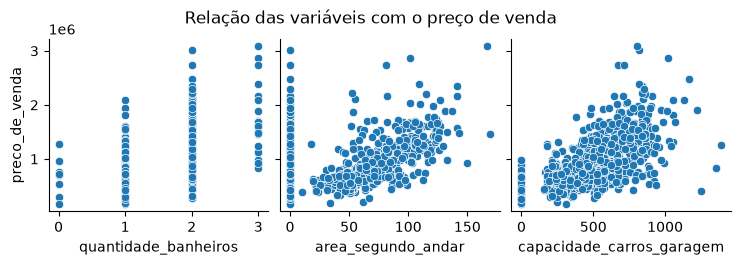

In [11]:
sns.pairplot(dados, y_vars='preco_de_venda',
             x_vars=['quantidade_banheiros', 'area_segundo_andar', 'capacidade_carros_garagem'])
plt.suptitle('Relação das variáveis com o preço de venda', y=1.02)
plt.show()

`capacidade_carros_garagem` pode ser nenhuma (0) visto isso sigo com o atributo `area_primeiro_andar`.

### 2.2 Correlacionando a área construída ao preço do imóvel

O próximo passo será fazer a relação entre área do primeiro andar ( area_primeiro_andar ) e preço de venda ( preco_de_venda ). Para isso, chamaremos o método plt.scatter() em uma nova célula.

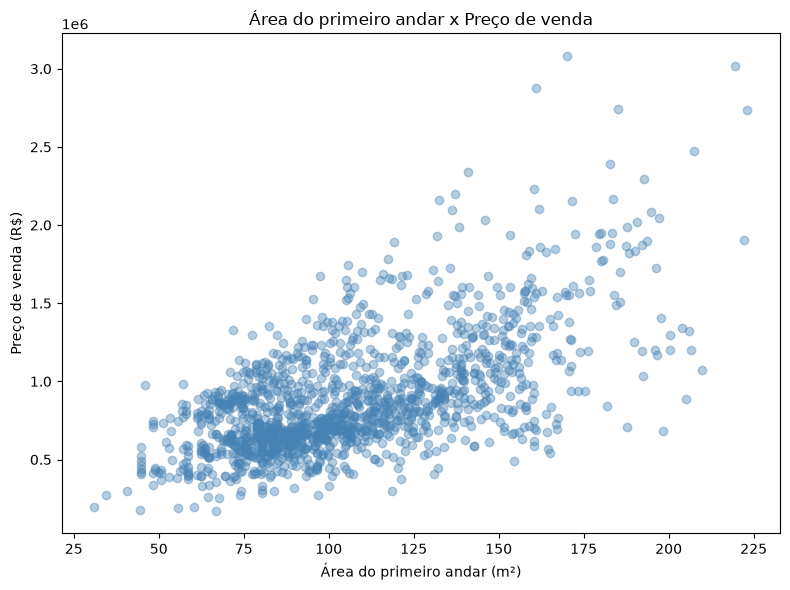

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(dados['area_primeiro_andar'], dados['preco_de_venda'], alpha=0.4, color='steelblue')
plt.title('Área do primeiro andar x Preço de venda')
plt.xlabel('Área do primeiro andar (m²)')
plt.ylabel('Preço de venda (R$)')
plt.tight_layout()
plt.show()


A nuvem de pontos confirma a tendência positiva: imóveis com primeiro andar maior tendem a custar mais. A dispersão é considerável, o que indica que a área sozinha não é suficiente para explicar o preço.


### 2.3 Obtendo a Melhor Reta
Uma maneira de estabelecer a **melhor reta** , isto é, a reta mais centralizada dos pontos, é com o auxílio da **biblioteca** que importamos anteriormente: a biblioteca `plotly` , que possui um recurso que para gerar a melhor reta.

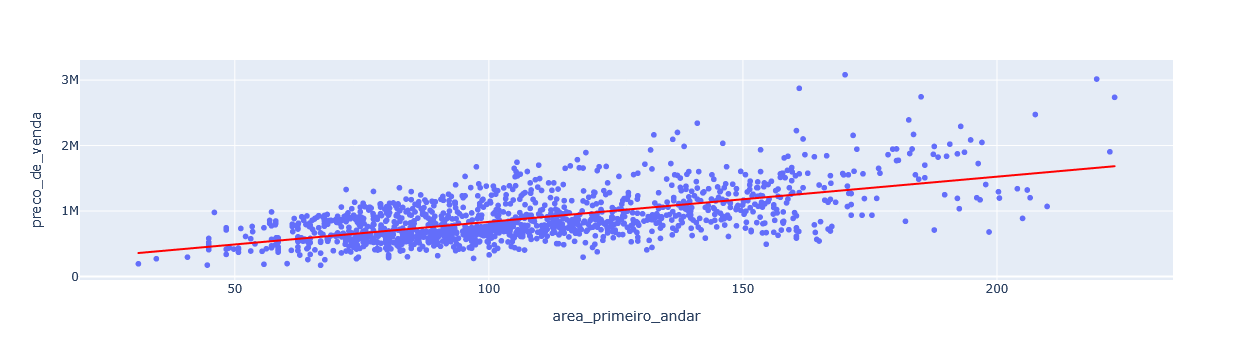

In [4]:
px.scatter(dados, 
           x = 'area_primeiro_andar',
           y = 'preco_de_venda',
           trendline_color_override="red",
           trendline = 'ols' )

Foi gerado um gráfico com a **melhor representação linear** entre área e preço, justamente por utilizar o método `ols` para trazer uma linha mais ajustada. Para ajustar a reta, elencamos uma **variável explicativa** (X), que no nosso caso, é a área do primeiro andar ( `area_primeiro_andar` ). Depois, trouxemos uma **variável resposta** (Y), ou seja, o preço de venda ( `preco_de_venda` ). Portanto, a área do primeiro andar explica o preço de venda.

Essa representação linear é melhor vista com uma **reta** , de fórmula generalizada:

> Yᵢ = B₀ + B₁ * Xᵢ

---


## 3. Modelo 0: regressão simples

Ajusto o primeiro modelo usando apenas `area_primeiro_andar` como variável explicativa. É o ponto de partida para entender o quanto uma única variável consegue explicar.


In [12]:
df_treino_m0 = dados.copy()
modelo_0 = smf.ols('preco_de_venda ~ area_primeiro_andar', data=df_treino_m0).fit()
print(modelo_0.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.380
Method:                 Least Squares   F-statistic:                     880.7
Date:                Wed, 24 Jun 2026   Prob (F-statistic):          2.50e-151
Time:                        17:53:31   Log-Likelihood:                -20132.
No. Observations:                1438   AIC:                         4.027e+04
Df Residuals:                    1436   BIC:                         4.028e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.448e+05   2

A equação do modelo 0 é:

> **preco_de_venda = 144.800 + 6.899,19 × area_primeiro_andar**

O intercepto (R\\$ 144.800) não tem interpretação prática direta. O coeficiente da área (R\\$ 6.899,19 por m²) indica que cada metro quadrado adicional no primeiro andar eleva o preço médio esperado em R$ 6.899,19. Ambos são estatisticamente significativos (p < 0,001). O R² de 0,38 significa que apenas 38% da variação nos preços é explicada pela área do primeiro andar. Preciso de mais variáveis.



---



## 4. Separando em treino e teste

Antes de construir os modelos múltiplos, separo os dados em treino (70%) e teste (30%). O conjunto de teste permanece fora do treinamento e serve para avaliar a capacidade do modelo de generalizar para imóveis não vistos.


In [14]:
y = dados['preco_de_venda']
X = dados.drop(columns='preco_de_venda')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=230)

print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste:  {X_test.shape[0]} registros")

Treino: 1006 registros
Teste:  432 registros


In [15]:
df_train = X_train.copy()
df_train['preco_de_venda'] = y_train

modelo_0 = smf.ols('preco_de_venda ~ area_primeiro_andar', data=df_train).fit()

print(f"R² (treino): {modelo_0.rsquared:.4f}")
print(f"R² (teste):  {r2_score(y_test, modelo_0.predict(X_test['area_primeiro_andar'])):.4f}")

R² (treino): 0.3773
R² (teste):  0.3853


Os valores de R² em treino e teste estão muito próximos, o que indica ausência de overfitting no modelo 0. O problema não é que ele "memorizou" os dados de treino; é que um único preditor simplesmente não é suficiente.


---



## 5. Modelos 1, 2 e 3: regressão múltipla

Para os modelos múltiplos, uso `statsmodels.api.OLS` e adiciono a constante manualmente com `sm.add_constant`.


In [16]:
X_train_c = sm.add_constant(X_train)
X_test_c  = sm.add_constant(X_test)


### 5.1 Modelo 1 - todas as variáveis


In [21]:
cols1 = ['const', 'area_primeiro_andar', 'existe_segundo_andar',
         'area_segundo_andar', 'quantidade_banheiros',
         'capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente']

modelo_1 = sm.OLS(y_train, X_train_c[cols1]).fit()
print(f"R² (treino): {modelo_1.rsquared:.4f}")
# print(modelo_1.summary())

R² (treino): 0.7414


Com todas as seis variáveis, o R² sobe para 0,74. Mas esse modelo inclui `area_segundo_andar` e `existe_segundo_andar` juntas, duas variáveis que descrevem o mesmo elemento do imóvel e podem introduzir multicolinearidade. Verifico isso na seção 8.


### 5.2 Modelo 2 - sem área do segundo andar


In [18]:
cols2 = ['const', 'area_primeiro_andar', 'existe_segundo_andar',
         'quantidade_banheiros', 'capacidade_carros_garagem',
         'qualidade_da_cozinha_Excelente']

modelo_2 = sm.OLS(y_train, X_train_c[cols2]).fit()
print(f"R² (treino): {modelo_2.rsquared:.4f}")

R² (treino): 0.7081


Ao remover `area_segundo_andar`, o R² cai para 0,71. A variável contribuía com algo, mas a um custo de colinearidade com `existe_segundo_andar`.

### 5.3 Modelo 3 - sem garagem e sem área do segundo andar

In [22]:
cols3 = ['const', 'area_primeiro_andar', 'existe_segundo_andar',
         'quantidade_banheiros', 'qualidade_da_cozinha_Excelente']

modelo_3 = sm.OLS(y_train, X_train_c[cols3]).fit()
print(modelo_3.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     467.1
Date:                Wed, 24 Jun 2026   Prob (F-statistic):          4.15e-227
Time:                        18:33:11   Log-Likelihood:                -13790.
No. Observations:                1006   AIC:                         2.759e+04
Df Residuals:                    1001   BIC:                         2.762e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

O modelo 3 tem R² = 0,65 com quatro variáveis, todas altamente significativas (p < 0,001). A equação resultante é:

> **preco_de_venda = -129.980 + 6.119,65 × area_primeiro_andar + 221.307 × existe_segundo_andar + 149.036 × quantidade_banheiros + 444.391 × qualidade_da_cozinha_Excelente**



---


## 6. Comparando os modelos

In [23]:
pred_3 = modelo_3.predict(X_test_c[cols3])

print("R² (treino):")
print(f"  Modelo 0 (1 var):  {modelo_0.rsquared:.4f}")
print(f"  Modelo 1 (6 vars): {modelo_1.rsquared:.4f}")
print(f"  Modelo 2 (5 vars): {modelo_2.rsquared:.4f}")
print(f"  Modelo 3 (4 vars): {modelo_3.rsquared:.4f}")
print(f"\nR² (teste):")
print(f"  Modelo 0:          {r2_score(y_test, modelo_0.predict(X_test['area_primeiro_andar'])):.4f}")
print(f"  Modelo 3:          {r2_score(y_test, pred_3):.4f}")

R² (treino):
  Modelo 0 (1 var):  0.3773
  Modelo 1 (6 vars): 0.7414
  Modelo 2 (5 vars): 0.7081
  Modelo 3 (4 vars): 0.6511

R² (teste):
  Modelo 0:          0.3853
  Modelo 3:          0.6432


| Modelo | Variáveis | R² treino | R² teste |
|--------|-----------|-----------|----------|
| Modelo 0 | `area_primeiro_andar` | 0,3773 | 0,3853 |
| Modelo 1 | Todas (6) | 0,7414 | , |
| Modelo 2 | Sem `area_segundo_andar` | 0,7081 | , |
| Modelo 3 | Sem garagem e sem área 2º | 0,6511 | **0,6432** |

Seleciono o modelo 3 para a etapa de precificação. O modelo 1 tem o maior R² no treino, mas depende de `capacidade_carros_garagem` e `area_segundo_andar`, variáveis ausentes no arquivo de novas casas. O modelo 3 resolve esse problema e ainda generaliza bem: a diferença entre R² de treino (0,6511) e de teste (0,6432) é mínima.



---


## 7. Precificando imóveis novos

### 7.1 Interpretação dos coeficientes

Cada variável contribui de forma aditiva ao preço estimado:

| Variável | Coeficiente | Interpretação |
|---|---|---|
| Intercepto | -R\\$ 129.980 | Valor base sem interpretação prática direta |
| `area_primeiro_andar` | +R\\$ 6.119,65/m² | Cada metro quadrado adicional eleva o preço em R\\$ 6.119,65 |
| `existe_segundo_andar` | +R\\$ 221.307 | Ter segundo andar adiciona R\\$ 221.307 ao preço esperado |
| `quantidade_banheiros` | +R\\$ 149.036/unidade | Cada banheiro extra vale R\\$ 149.036 |
| `qualidade_da_cozinha_Excelente` | +R\\$ 444.391 | Cozinha excelente é o fator de maior impacto unitário no modelo |



### 7.2 Precificando um imóvel específico


In [24]:
novo_imovel = pd.DataFrame({
    'const':                          [1],
    'area_primeiro_andar':            [120],
    'existe_segundo_andar':           [1],
    'quantidade_banheiros':           [2],
    'qualidade_da_cozinha_Excelente': [0]
})

preco_previsto = modelo_3.predict(novo_imovel)[0]
print(f"Preço estimado: R$ {preco_previsto:,.2f}")

Preço estimado: R$ 1,123,758.24


Para um imóvel com 120 m² no primeiro andar, segundo andar presente, 2 banheiros e cozinha padrão, o modelo estima R$ 1.123.758,24.


### 7.3 Precificando lote de novas casas


In [35]:
try:
    novas_casas = pd.read_csv("Novas_casas.csv", sep=";")
    novas_casas_modelo = novas_casas.drop(columns="Casa")
    novas_casas_c = sm.add_constant(novas_casas_modelo)

    previsoes = modelo_3.predict(novas_casas_c)

    resultado = novas_casas[['Casa']].copy()
    resultado['preco_previsto'] = previsoes.map('R$ {:,.2f}'.format)
    # display(novas_casas)
    # print(resultado.to_string(index=False))
    display(novas_casas.merge(resultado, on='Casa'))

except FileNotFoundError:
    print('Erro ao carregar arquivo, verifique o caminho.')
except Exception as e:
    print(f'Erro: {str(e)}')


,Casa,area_primeiro_andar,existe_segundo_andar,quantidade_banheiros,qualidade_da_cozinha_Excelente,preco_previsto
0,1,150,1,2,1,"R$ 1,751,739.07"
1,2,180,0,3,1,"R$ 1,863,057.99"
2,3,120,1,2,1,"R$ 1,568,149.47"
3,4,200,1,3,1,"R$ 2,206,758.02"
4,5,160,0,2,1,"R$ 1,591,628.64"
5,6,140,1,2,0,"R$ 1,246,151.31"
6,7,170,0,3,0,"R$ 1,357,470.23"
7,8,190,1,2,0,"R$ 1,552,133.97"
8,9,130,0,2,0,"R$ 963,647.81"
9,10,180,1,3,0,"R$ 1,639,973.72"


As casas 1 a 5 têm `qualidade_da_cozinha_Excelente = 1`, o que eleva os preços estimados em relação às casas 6 a 10. A casa 9, sem segundo andar e sem cozinha excelente, apresenta o menor preço do lote.



---



## 8. Avaliando o modelo: VIF e resíduos


### 8.1 Multicolinearidade (VIF)

Multicolinearidade ocorre quando variáveis explicativas estão altamente correlacionadas entre si, o que dificulta isolar o efeito individual de cada uma nos coeficientes. O **Fator de Inflação da Variância (VIF)** quantifica isso: valores próximos de 1 indicam ausência de colinearidade; valores acima de 5 são motivo de atenção.


In [36]:
vif_3 = pd.DataFrame()
vif_3['variavel'] = cols3
vif_3['vif'] = [variance_inflation_factor(X_train_c[cols3].values, i)
                for i in range(len(cols3))]
print(vif_3)

                         variavel        vif
0                           const  18.773457
1             area_primeiro_andar   1.919046
2            existe_segundo_andar   1.644067
3            quantidade_banheiros   1.539255
4  qualidade_da_cozinha_Excelente   1.151795



O VIF da constante é alto por construção matemática e não representa problema. Para todas as variáveis explicativas, o VIF fica entre 1,15 e 1,92, bem abaixo do limiar de 5. O modelo 3 está livre de multicolinearidade relevante.

Para comparação, o modelo 1 apresenta VIF elevado justamente nas variáveis problemáticas:


In [37]:
vif_1 = pd.DataFrame()
vif_1['variavel'] = cols1
vif_1['vif'] = [variance_inflation_factor(X_train_c[cols1].values, i)
                for i in range(len(cols1))]
print(vif_1)

                         variavel        vif
0                           const  20.230833
1             area_primeiro_andar   2.193680
2            existe_segundo_andar   7.455059
3              area_segundo_andar   7.589396
4            quantidade_banheiros   1.720795
5       capacidade_carros_garagem   1.570078
6  qualidade_da_cozinha_Excelente   1.182606


`existe_segundo_andar` e `area_segundo_andar` têm VIF acima de 7 no modelo 1, confirmando que as duas variáveis carregam informação redundante. A remoção de `area_segundo_andar` no modelo 3 resolve o problema.


### 8.2 Análise de resíduos

Os resíduos são as diferenças entre os valores reais e os valores previstos pelo modelo. Em um bom modelo de regressão linear, espero resíduos distribuídos de forma aleatória ao redor de zero, sem padrões sistemáticos. Esse comportamento se chama **homocedasticidade**. Quando os resíduos formam padrões, como um cone ou uma parábola, temos **heterocedasticidade**, indicando que a variância dos erros não é constante.


In [38]:
y_previsto_train = modelo_3.predict(X_train_c[cols3])
residuos = modelo_3.resid

fig = px.scatter(x=y_previsto_train, y=y_train,
                 title='Previsão x Real (treino)',
                 labels={'x': 'Preço previsto', 'y': 'Preço real'})
fig.show()

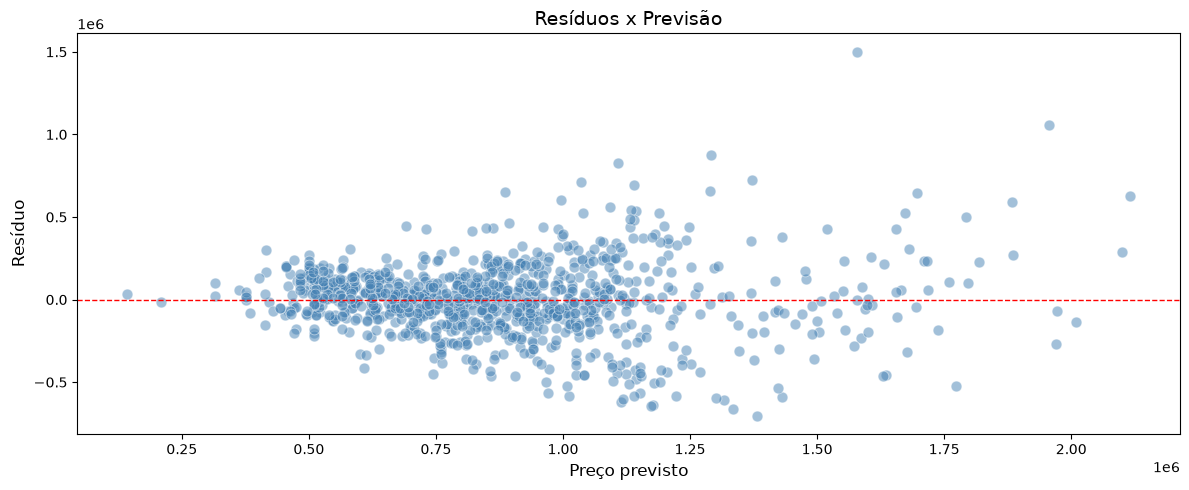

In [39]:
ax = sns.scatterplot(x=y_previsto_train, y=residuos, s=60, alpha=0.5, color='steelblue')
ax.figure.set_size_inches(12, 5)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Resíduos x Previsão', fontsize=14)
ax.set_xlabel('Preço previsto', fontsize=12)
ax.set_ylabel('Resíduo', fontsize=12)
plt.tight_layout()
plt.show()


O gráfico de resíduos do modelo 3 apresenta indício de heterocedasticidade: os erros se tornam mais dispersos à medida que o preço previsto aumenta, formando um padrão de cone. Isso é comum em dados imobiliários, onde imóveis de alto padrão têm maior variabilidade de preço. O modelo erra mais nos imóveis mais caros, o que sugere que variáveis adicionais, como localização ou qualidade geral da construção, seriam necessárias para capturar melhor essa faixa.



---


## 9. Conclusão


### Síntese dos resultados

| Métrica | Valor |
|---|---|
| Observações no dataset | 1.438 |
| Proporção treino / teste | 70% / 30% |
| R² Modelo 0 (1 variável, teste) | 0,3853 |
| R² Modelo 3 (4 variáveis, treino) | 0,6511 |
| R² Modelo 3 (4 variáveis, teste) | **0,6432** |
| VIF máximo, variáveis explicativas | 1,92 |
| Maior coeficiente | `qualidade_da_cozinha_Excelente` (+R\\$ 444.391) |

### Achados principais

Partindo de um único preditor com R² ≈ 0,38, chego ao modelo 3 com quatro variáveis e R² ≈ 0,64 no conjunto de teste. O ganho é expressivo sem sacrificar interpretabilidade. A variável de maior impacto unitário é `qualidade_da_cozinha_Excelente` (+R\\$ 444.391), seguida por `existe_segundo_andar` (+R\\$ 221.307) e `quantidade_banheiros` (+R\\$ 149.036 por unidade). A área do primeiro andar contribui de forma contínua com R\\$ 6.120 por m². O VIF do modelo 3 confirma ausência de multicolinearidade relevante em todas as variáveis explicativas.

### Limitações

O dataset é simplificado em relação ao original do Kaggle, que possui 80 variáveis. Localização, ano de construção e qualidade geral da construção têm impacto substancial no preço real e estão ausentes aqui. Os resíduos apresentam heterocedasticidade, indicando que a variância dos erros não é constante na faixa de preços mais altos. Uma transformação logarítmica na variável resposta poderia atenuar esse problema. Por fim, a regressão linear assume relações lineares entre preditores e resposta; modelos como Random Forest ou Gradient Boosting poderiam capturar interações e não-linearidades que o OLS não detecta.



---



## 10. Referências

- Alura. **Data Science: testando relações com Regressão Linear**. Disponível em: [https://www.alura.com.br/curso-online-data-science-testando-relacoes-regressao-linear](https://www.alura.com.br/curso-online-data-science-testando-relacoes-regressao-linear). Acesso em: jun. 2026.

- Kaggle. **House Prices: Advanced Regression Techniques**. Disponível em: [https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques). Acesso em: jun. 2026.

- Statsmodels. **Regression and Linear Models**. Disponível em: [https://www.statsmodels.org/stable/regression.html](https://www.statsmodels.org/stable/regression.html). Acesso em: jun. 2026.

- ESALQ/USP. **Análise de Regressão**. Disponível em: [https://www.esalq.usp.br/biblioteca/sites/default/files/Analise_Regressão.pdf](https://www.esalq.usp.br/biblioteca/sites/default/files/Analise_Regressão.pdf). Acesso em: jun. 2026.

- Scikit-learn. **sklearn.model_selection.train_test_split**. Disponível em: [https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). Acesso em: jun. 2026.